## Import the libraries

In [6]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

## 2. Data Collection - Import the dataset

In [7]:
Claimants_data = pd.read_csv("claimants.csv")
Claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## 3. Data Understanding

In [8]:
Claimants_data.shape

(1340, 7)

In [9]:
Claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [10]:
Claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

## 4. Data Preparation

In [11]:
## Remove the null values

Claimants_data.dropna(inplace = True)
Claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [12]:
Claimants_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

In [13]:
## Split training and testing data

X = Claimants_data.drop(["CASENUM","ATTORNEY"], axis = 1)
X


,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [14]:
y = Claimants_data["ATTORNEY"]
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

## 5. Model Building

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, shuffle = True, random_state=20)

In [16]:
X_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
739,0.0,1.0,0.0,6.0,4.076
637,0.0,1.0,0.0,44.0,3.900
798,1.0,1.0,0.0,8.0,1.354
225,0.0,1.0,0.0,19.0,1.644
806,1.0,1.0,0.0,50.0,3.348
...,...,...,...,...,...
1210,0.0,1.0,0.0,80.0,0.347
480,0.0,1.0,0.0,47.0,0.090
1127,1.0,1.0,0.0,6.0,0.060
326,1.0,1.0,0.0,0.0,0.057


## Model Using Random Forest

## 6. Model Training

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators=75, max_depth= 5)

rf_classifier.fit(X_train, y_train)

,n_estimators,75
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
from sklearn.model_selection import GridSearchCV


grid_search = GridSearchCV(estimator =rf_classifier,param_grid = {"max_depth":[5,6,7,8,9,10],"criterion":["entropy","gini"],"n_estimators":[50,75,100,150]} )
 
grid_search.fit(X,y)

print(grid_search.best_params_)
print(grid_search.best_estimator_)

{'criterion': 'gini', 'max_depth': 5, 'n_estimators': 75}
RandomForestClassifier(max_depth=5, n_estimators=75)


## 7.  Model Testing

In [37]:
y_pred_train  = rf_classifier.predict(X_train)

In [38]:
y_pred_train

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,

In [39]:
### Test Data

y_pred_test  = rf_classifier.predict(X_test)
y_pred_test

array([0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1])

## 8. Model Evaluation

### Training Data Evaluation Metrics

In [40]:
print(confusion_matrix(y_train,y_pred_train))

[[375  93]
 [123 285]]


In [41]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.75      0.80      0.78       468
           1       0.75      0.70      0.73       408

    accuracy                           0.75       876
   macro avg       0.75      0.75      0.75       876
weighted avg       0.75      0.75      0.75       876



In [42]:
accuracy_score(y_train,y_pred_train)

0.7534246575342466

### Test Data Evaluation Metrics

In [43]:
print(confusion_matrix(y_test,y_pred_test))

[[88 22]
 [40 70]]


In [44]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.69      0.80      0.74       110
           1       0.76      0.64      0.69       110

    accuracy                           0.72       220
   macro avg       0.72      0.72      0.72       220
weighted avg       0.72      0.72      0.72       220



In [45]:
accuracy_score(y_test,y_pred_test)

0.7181818181818181

AUC: 0.7611157024793389


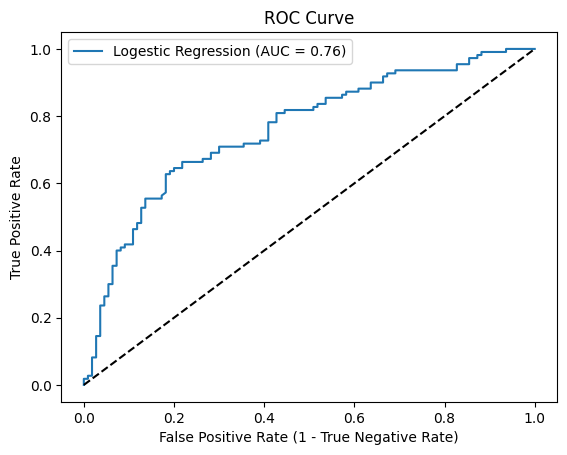

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability of class 1
y_prob = rf_classifier.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

# Plot ROC curve
plt.plot(fpr, tpr, label='Logestic Regression (AUC = %.2f)' % auc)

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate (1 - True Negative Rate)')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Model Using Adaboost

In [51]:
from sklearn.ensemble import AdaBoostClassifier


[[355 113]
 [123 285]]
              precision    recall  f1-score   support

           0       0.74      0.76      0.75       468
           1       0.72      0.70      0.71       408

    accuracy                           0.73       876
   macro avg       0.73      0.73      0.73       876
weighted avg       0.73      0.73      0.73       876

0.730593607305936
[[84 26]
 [38 72]]
              precision    recall  f1-score   support

           0       0.69      0.76      0.72       110
           1       0.73      0.65      0.69       110

    accuracy                           0.71       220
   macro avg       0.71      0.71      0.71       220
weighted avg       0.71      0.71      0.71       220

0.7090909090909091
AUC: 0.7734297520661156


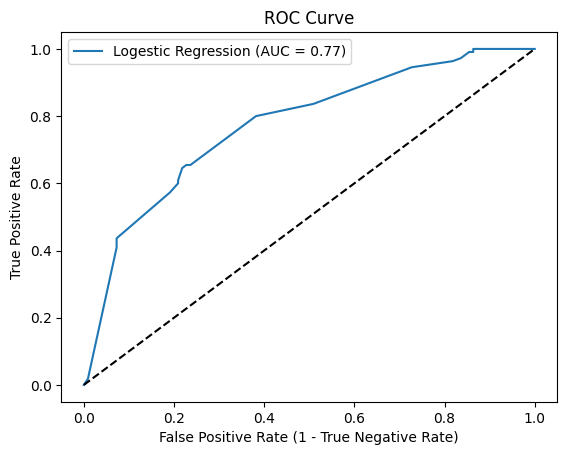

In [55]:
adaboost_classifier = AdaBoostClassifier()

adaboost_classifier.fit(X_train, y_train)

y_pred_train  = adaboost_classifier.predict(X_train)
y_pred_test  = adaboost_classifier.predict(X_test)


## For training data
print(confusion_matrix(y_train,y_pred_train))
print(classification_report(y_train,y_pred_train))
print(accuracy_score(y_train,y_pred_train))

## For Test Data
print(confusion_matrix(y_test,y_pred_test))
print(classification_report(y_test,y_pred_test))
print(accuracy_score(y_test,y_pred_test))


from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability of class 1
y_prob = adaboost_classifier.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

# Plot ROC curve
plt.plot(fpr, tpr, label='Logestic Regression (AUC = %.2f)' % auc)

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate (1 - True Negative Rate)')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Model Using Stacking

In [56]:
## Not useful for modelling in real time

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

# Create individual models
logistic_classifier = LogisticRegression()
dt_classifier = DecisionTreeClassifier()
knn_classifier = KNeighborsClassifier()

# Combine the models
voting_classifier = VotingClassifier(
    estimators=[
        ("logistic_model", logistic_classifier),
        ("dt_model", dt_classifier),
        ("knn_model", knn_classifier)
    ]
)

# Train the combined model
voting_classifier.fit(X, y)

# Make predictions
y_pred = voting_classifier.predict(X)

# Check accuracy
accuracy_score(y, y_pred)

0.8394160583941606